# Weekly User Churn Case Study

Predicting next-week inactivity from weekly user activity.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

import statsmodels.formula.api as smf
from scipy import stats

RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")

## 1. Load the weekly panel and perform a minimal audit

In [2]:
df_raw = pd.read_csv("weekly_user_activity_raw.csv", parse_dates=["week_start"])
print("Raw shape:", df_raw.shape)
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("Date range:", df_raw["week_start"].min(), "to", df_raw["week_start"].max())
print("Users:", df_raw["user_id"].nunique())
print("Avg weeks per user:", round(df_raw.shape[0] / df_raw["user_id"].nunique(), 1))
display(df_raw.isna().sum().to_frame("missing_count"))

Raw shape: (19876, 14)
Duplicate rows: 25
Date range: 2024-01-01 00:00:00 to 2025-02-17 00:00:00
Users: 2500
Avg weeks per user: 8.0


,missing_count
user_id,0
week_start,0
plan_type,0
region,0
acquisition_channel,0
weekly_sessions,0
weekly_minutes,0
distinct_days_active,0
support_tickets_week,0
payment_failure_flag,0


This is a weekly panel: ~2,500 users observed over ~60 weeks, with roughly 8 rows per user on average. Three columns have non-trivial missingness (push_open_rate, feature_adoption_ratio, weekly_spend) — I will check later whether missingness is correlated with churn.

The target will be operational rather than contractual: a user is labeled as churned at week *t* if there is no activity at week *t+1*. This makes the target reactive and well-suited for threshold-based intervention analysis.

## 2. Target construction and protected holdout

In [3]:
df = df_raw.sort_values(["user_id", "week_start"]).drop_duplicates().reset_index(drop=True).copy()

df["next_week"] = df.groupby("user_id")["week_start"].shift(-1)
df["expected_next_week"] = df["week_start"] + pd.Timedelta(days=7)
max_week = df["week_start"].max()

df["churn_next_week"] = np.where(
    df["week_start"] == max_week,
    np.nan,
    (df["next_week"] != df["expected_next_week"]).astype(int)
)

# Tenure is a simple count — safe to compute here, needed for EDA
df["tenure_weeks"] = df.groupby("user_id").cumcount() + 1

df = df.dropna(subset=["churn_next_week"]).copy()
df["churn_next_week"] = df["churn_next_week"].astype(int)

# ── Protected holdout: last 20% of calendar weeks ──
unique_weeks = np.sort(df["week_start"].unique())
holdout_cut = int(len(unique_weeks) * 0.80)
dev_weeks = unique_weeks[:holdout_cut]
holdout_weeks = unique_weeks[holdout_cut:]

dev_df = df[df["week_start"].isin(dev_weeks)].copy()
holdout_df = df[df["week_start"].isin(holdout_weeks)].copy()

display(pd.DataFrame({
    "sample": ["dev", "holdout"],
    "rows": [len(dev_df), len(holdout_df)],
    "start": [dev_df["week_start"].min(), holdout_df["week_start"].min()],
    "end": [dev_df["week_start"].max(), holdout_df["week_start"].max()],
    "churn_rate": [dev_df["churn_next_week"].mean(), holdout_df["churn_next_week"].mean()],
}))
print(f"\nTarget rate (full): {df['churn_next_week'].mean():.4f}")
print(f"Total churn events: {int(df['churn_next_week'].sum())}")
print(f"Modeling rows: {len(df)}")

,sample,rows,start,end,churn_rate
0,dev,17328,2024-01-01,2024-11-18,0.128982
1,holdout,2387,2024-11-25,2025-02-10,0.054043



Target rate (full): 0.1199
Total churn events: 2364
Modeling rows: 19715


The split is by calendar week — the last 20% of weeks are held out as a protected evaluation set. All EDA, feature engineering, and model selection use the development partition only. The train/test split within the development set is deferred to §5.

The churn rate drops from **12.9% (dev) to 5.4% (holdout)**. This is a critical observation: either the product is improving, or the user base is maturing, or both. Any model trained on earlier data will face a distributional shift on the holdout. This needs to be kept in mind when interpreting holdout performance.

## 3. EDA — development sample only

### 3.1 Temporal dynamics

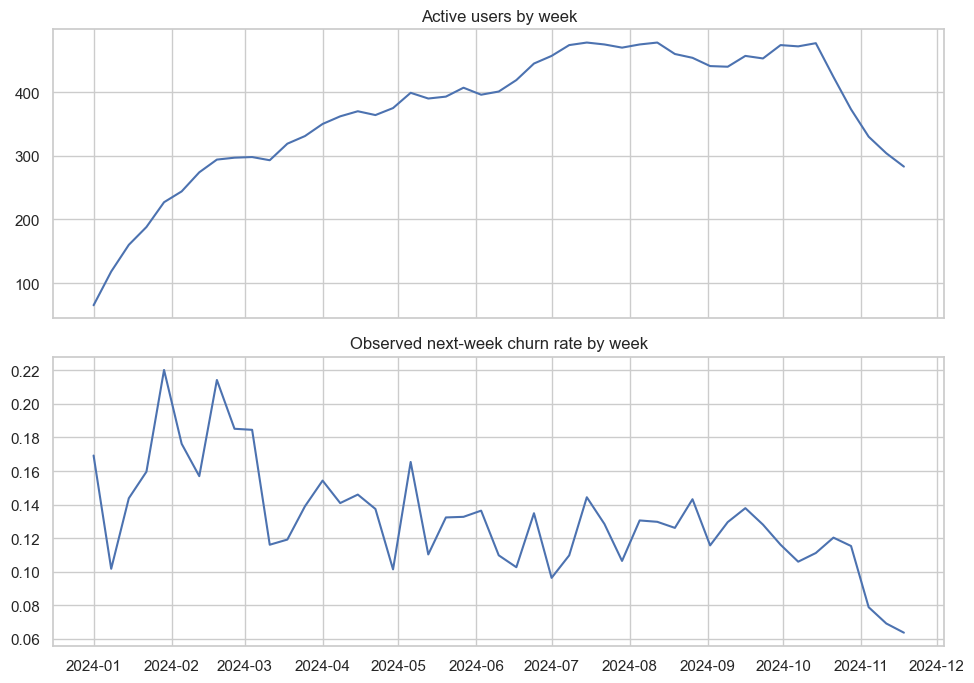

In [4]:
%matplotlib inline

eda_df = dev_df.copy()

weekly_counts = eda_df.groupby("week_start").agg(
    active_users=("user_id", "nunique"), 
    churn_rate=("churn_next_week", "mean")
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(weekly_counts["week_start"], weekly_counts["active_users"])
axes[0].set_title("Active users by week")
axes[1].plot(weekly_counts["week_start"], weekly_counts["churn_rate"])
axes[1].set_title("Observed next-week churn rate by week")
plt.tight_layout()
plt.show()

The user base is growing while the churn rate is declining — both trends are clear and persistent. This has two implications for modeling: (1) the target distribution is non-stationary, so a temporal split is essential, and (2) a feature capturing "where we are in time" (e.g. a week index or trend proxy) could help the model adapt to this drift.

### 3.2 Sanity checks and outliers

In [5]:
expected_bounds = {
    "weekly_sessions": (0, np.inf),
    "weekly_minutes": (0, np.inf),
    "distinct_days_active": (1, 7),
    "support_tickets_week": (0, np.inf),
    "payment_failure_flag": (0, 1),
    "push_open_rate": (0, 1),
    "feature_adoption_ratio": (0, 1),
    "marketing_touches": (0, np.inf),
    "weekly_spend": (0, np.inf),
}
rows = []
for col, (low, high) in expected_bounds.items():
    s = eda_df[col]
    invalid = ((s < low) | (s > high)) & s.notna()
    rows.append({"column": col, "invalid_count": int(invalid.sum()), "observed_min": s.min(skipna=True), "observed_max": s.max(skipna=True)})
display(pd.DataFrame(rows).sort_values("invalid_count", ascending=False))

,column,invalid_count,observed_min,observed_max
0,weekly_sessions,0,0.0,23.0000
1,weekly_minutes,0,5.0,219.1200
2,distinct_days_active,0,1.0,7.0000
3,support_tickets_week,0,0.0,4.0000
4,payment_failure_flag,0,0.0,1.0000
5,push_open_rate,0,0.0,0.6824
6,feature_adoption_ratio,0,0.0,1.0000
7,marketing_touches,0,0.0,8.0000
8,weekly_spend,0,0.0,101.7600


In [6]:
# Outlier check on raw numeric columns (no engineered features yet)
raw_numeric_cols = ["weekly_sessions", "weekly_minutes", "distinct_days_active", 
                    "support_tickets_week", "payment_failure_flag", "push_open_rate",
                    "feature_adoption_ratio", "marketing_touches", "weekly_spend", "tenure_weeks"]

outlier_rows = []
for col in raw_numeric_cols:
    s = eda_df[col].dropna()
    z = (s - s.mean()) / s.std() if s.std() > 0 else pd.Series(0, index=s.index)
    outlier_rows.append({"feature": col, "p01": s.quantile(0.01), "p99": s.quantile(0.99), 
                         "mean": s.mean(), "std": s.std(), 
                         "abs_z_gt_3_pct": round(float((z.abs() > 3).mean() * 100), 2)})
outlier_df = pd.DataFrame(outlier_rows).sort_values("abs_z_gt_3_pct", ascending=False)
display(outlier_df)

,feature,p01,p99,mean,std,abs_z_gt_3_pct
4,payment_failure_flag,0.0000,1.000000,0.054478,0.226966,5.45
7,marketing_touches,0.0000,4.000000,0.880540,1.006435,2.06
9,tenure_weeks,1.0000,38.000000,9.182999,8.926874,1.65
3,support_tickets_week,0.0000,2.000000,0.313193,0.574828,0.62
5,push_open_rate,0.0000,0.488904,0.154536,0.123302,0.52
0,weekly_sessions,1.0000,15.000000,6.623038,3.205039,0.39
1,weekly_minutes,18.1635,159.470300,81.747253,30.555699,0.33
8,weekly_spend,7.3347,80.255300,40.899262,16.406899,0.19
2,distinct_days_active,1.0000,7.000000,2.875693,1.419839,0.00
6,feature_adoption_ratio,0.0648,1.000000,0.564349,0.285969,0.00


No impossible values. payment_failure_flag has the highest outlier rate at 5.45% (mechanical — it is binary), followed by marketing_touches at 2.06%. The continuous activity features (sessions, minutes, spend) all show less than 0.4% beyond |z|>3. No winsorization needed.

### 3.3 Missing values

In [7]:
missing_cols = ["push_open_rate", "feature_adoption_ratio", "weekly_spend"]

for col in missing_cols:
    rate_miss = eda_df.loc[eda_df[col].isna(), "churn_next_week"].mean()
    rate_obs = eda_df.loc[eda_df[col].notna(), "churn_next_week"].mean()
    print(f"{col}: churn rate when missing = {rate_miss:.4f}, when observed = {rate_obs:.4f}")

push_open_rate: churn rate when missing = 0.1402, when observed = 0.1288
feature_adoption_ratio: churn rate when missing = 0.1358, when observed = 0.1289
weekly_spend: churn rate when missing = 0.1348, when observed = 0.1289


--> Missingness shows a modest link with churn: missing push_open_rate has 14.0% churn vs 12.9% when observed, and similar small gaps for feature_adoption_ratio and weekly_spend. The differences are not dramatic, but creating missingness indicators is cheap and cannot hurt — I will add them during feature engineering.

### 3.4 Churn rate by categorical segment

In [8]:
for col in ["plan_type", "region", "acquisition_channel"]:
    print(col)
    display(eda_df.groupby(col)["churn_next_week"].agg(["mean", "count"]).sort_values("mean"))

plan_type


,mean,count
plan_type,,
premium,0.074251,4606
standard,0.112338,7335
basic,0.198441,5387


region


,mean,count
region,,
east,0.123578,4394
north,0.125115,4348
south,0.129109,4624
west,0.139071,3962


acquisition_channel


,mean,count
acquisition_channel,,
organic,0.109248,8348
partner,0.113737,3174
sales,0.115626,2707
paid,0.209422,3099


Clear gradient on plan_type (basic 20% vs premium 7%) and acquisition_channel (paid 21% vs organic 11%). Region effect is weak. This is consistent with the snapshot case — plan and channel are the two strongest categorical predictors.

### 3.5 Univariate profiling: churners vs non-churners

In [9]:
# Univariate profiling on raw features + tenure (already computed)
profile_cols = ["weekly_sessions", "weekly_minutes", "support_tickets_week", 
                "feature_adoption_ratio", "push_open_rate", "weekly_spend", 
                "tenure_weeks", "distinct_days_active", "marketing_touches",
                "payment_failure_flag"]
profile_rows = []
for col in profile_cols:
    g0 = eda_df.loc[eda_df["churn_next_week"] == 0, col].dropna()
    g1 = eda_df.loc[eda_df["churn_next_week"] == 1, col].dropna()
    profile_rows.append({"feature": col, "mean_non_churn": round(g0.mean(), 3), 
                         "mean_churn": round(g1.mean(), 3), 
                         "mean_diff": round(g1.mean() - g0.mean(), 3)})
profile_df = pd.DataFrame(profile_rows).sort_values("mean_diff")
display(profile_df)

,feature,mean_non_churn,mean_churn,mean_diff
1,weekly_minutes,85.054,59.419,-25.635
5,weekly_spend,42.566,29.637,-12.929
6,tenure_weeks,9.769,5.224,-4.545
0,weekly_sessions,6.979,4.216,-2.763
7,distinct_days_active,2.975,2.204,-0.772
3,feature_adoption_ratio,0.592,0.381,-0.211
4,push_open_rate,0.154,0.159,0.005
9,payment_failure_flag,0.047,0.107,0.060
2,support_tickets_week,0.288,0.485,0.197
8,marketing_touches,0.843,1.134,0.291


The strongest univariate separators are weekly_minutes (-25.6), weekly_spend (-12.9), tenure_weeks (-4.5) and weekly_sessions (-2.8). Churners are clearly less active, spend less, and are newer users.

Two findings worth noting: push_open_rate shows almost no difference (+0.005) between churners and non-churners — unlikely to be useful. On the other hand, marketing_touches is *higher* for churners (+0.29), and payment_failure_flag shows a clear positive gap (+0.06). Both suggest that operational friction and aggressive re-engagement efforts are associated with — though not necessarily causing — churn.

### 3.6 Pairwise relationships and interaction candidates

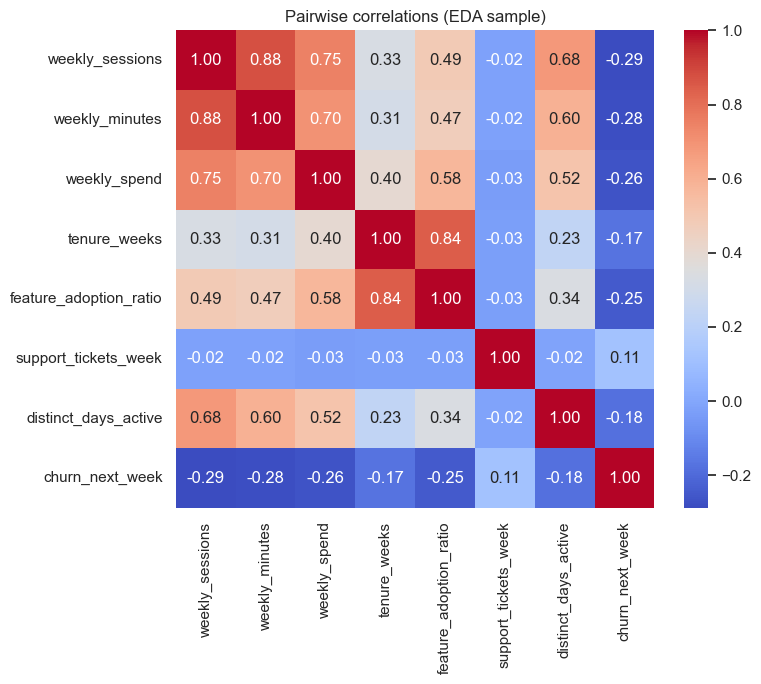

In [10]:
# Correlation on raw features only
corr_cols = ["weekly_sessions", "weekly_minutes", "weekly_spend", "tenure_weeks",
             "feature_adoption_ratio", "support_tickets_week", 
             "distinct_days_active", "churn_next_week"]
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(eda_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.title("Pairwise correlations (EDA sample)")
plt.tight_layout()
plt.show()

In [11]:
# Interaction candidates using raw features only
# 1. Low sessions + short tenure (new disengaged user)
eda_df["_new_low_engage"] = ((eda_df["tenure_weeks"] <= 4) & (eda_df["weekly_sessions"] <= 3)).astype(int)

# 2. Payment failure + support ticket (friction combo)
eda_df["_friction_flag"] = ((eda_df["payment_failure_flag"] == 1) & (eda_df["support_tickets_week"] >= 1)).astype(int)

# 3. Low adoption + low spend
eda_df["_low_adopt_low_spend"] = ((eda_df["feature_adoption_ratio"].fillna(0) < 0.3) & (eda_df["weekly_spend"].fillna(0) < 20)).astype(int)

int_rows = []
for name, col in [("new_low_engage", "_new_low_engage"), ("friction_flag", "_friction_flag"), ("low_adopt_low_spend", "_low_adopt_low_spend")]:
    g0 = eda_df.loc[eda_df[col] == 0, "churn_next_week"].mean()
    g1 = eda_df.loc[eda_df[col] == 1, "churn_next_week"].mean()
    n1 = int((eda_df[col] == 1).sum())
    int_rows.append({"interaction": name, "churn_when_0": round(g0, 4), "churn_when_1": round(g1, 4), 
                     "n_flagged": n1, "lift": round(g1 / g0, 2) if g0 > 0 else np.nan})
display(pd.DataFrame(int_rows))

eda_df.drop(columns=["_new_low_engage", "_friction_flag", "_low_adopt_low_spend"], inplace=True)

,interaction,churn_when_0,churn_when_1,n_flagged,lift
0,new_low_engage,0.0968,0.4046,1809,4.18
1,friction_flag,0.1258,0.3138,290,2.49
2,low_adopt_low_spend,0.1112,0.4085,1038,3.67


High redundancy between sessions, minutes and spend (corr > 0.7), which is expected — they all proxy engagement. The model should handle this via regularization.

The interaction analysis is more informative. **new_low_engage** (new users with low sessions) shows a 4.2x lift with 1,809 users flagged — the strongest subgroup signal. **low_adopt_low_spend** also shows a 3.7x lift on 1,038 users. **friction_flag** (payment failure + support ticket) has a 2.5x lift but on a smaller subgroup (290 users).

These results motivate creating trajectory and composite features in the engineering step. In particular, the session_drop concept (current sessions well below recent average) should capture a similar dynamic to new_low_engage but in a more continuous and general way.

## 4. Feature engineering and significance

This section engineers new features motivated by EDA findings, defines the feature set, and runs a logistic regression with robust standard errors to assess statistical significance before moving to ML models.

### 4.1 Engineered features

All features below are either lagged (using only past data) or computed from the current week's observables. No future information is used. The pre-existing features in the dataset (weekly_sessions, etc.) are assumed to be correctly timestamped, though in a production setting I would audit their construction.

In [12]:
# --- Lag and rolling features (causal: shifted by 1 week) ---
df["prev_sessions"] = df.groupby("user_id")["weekly_sessions"].shift(1)
df["prev_minutes"] = df.groupby("user_id")["weekly_minutes"].shift(1)
df["sessions_4w_avg"] = df.groupby("user_id")["weekly_sessions"].transform(
    lambda s: s.shift(1).rolling(4, min_periods=1).mean()
)
df["minutes_4w_avg"] = df.groupby("user_id")["weekly_minutes"].transform(
    lambda s: s.shift(1).rolling(4, min_periods=1).mean()
)
df["spend_4w_avg"] = df.groupby("user_id")["weekly_spend"].transform(
    lambda s: s.shift(1).rolling(4, min_periods=1).mean()
)
df["tickets_4w_sum"] = df.groupby("user_id")["support_tickets_week"].transform(
    lambda s: s.shift(1).rolling(4, min_periods=1).sum()
)
df["payment_fail_4w_sum"] = df.groupby("user_id")["payment_failure_flag"].transform(
    lambda s: s.shift(1).rolling(4, min_periods=1).sum()
)

# --- Deviation from recent baseline (motivated by EDA §3.1: trend matters) ---
df["sessions_vs_4w_avg"] = df["weekly_sessions"] - df["sessions_4w_avg"]
df["minutes_vs_4w_avg"] = df["weekly_minutes"] - df["minutes_4w_avg"]

# --- Low session streak (motivated by EDA §3.5: sustained low activity is a risk signal) ---
def low_streak(s):
    vals = []
    streak = 0
    for x in s.fillna(0):
        if x <= 2:
            streak += 1
        else:
            streak = 0
        vals.append(streak)
    return pd.Series(vals, index=s.index)

df["low_session_streak"] = df.groupby("user_id")["weekly_sessions"].apply(low_streak).reset_index(level=0, drop=True)

# --- Session drop flag (motivated by EDA §3.6: trajectory change) ---
df["session_drop_flag"] = (df["weekly_sessions"] < df["sessions_4w_avg"] * 0.5).astype(int)

# --- Missingness indicators (motivated by EDA §3.3) ---
for col in ["push_open_rate", "feature_adoption_ratio", "weekly_spend"]:
    df[f"{col}_missing"] = df[col].isna().astype(int)

# --- Week index as trend proxy (motivated by EDA §3.1: declining churn rate) ---
min_week = df["week_start"].min()
df["week_index"] = ((df["week_start"] - min_week).dt.days / 7).astype(int)

# ── Extract enriched splits ──
dev_fe = df[df["week_start"].isin(dev_weeks)].copy()
holdout_fe = df[df["week_start"].isin(holdout_weeks)].copy()

print("Features created. Dev churn rate:", round(dev_fe["churn_next_week"].mean(), 4))
print("Holdout churn rate:", round(holdout_fe["churn_next_week"].mean(), 4))

Features created. Dev churn rate: 0.129
Holdout churn rate: 0.054


In [13]:
target = "churn_next_week"
excluded_cols = {"user_id", "week_start", "next_week", "expected_next_week", "churn_next_week"}
features = [c for c in dev_fe.columns if c not in excluded_cols]

numeric_features = dev_fe[features].select_dtypes(include=np.number).columns.tolist()
categorical_features = dev_fe[features].select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Features: {len(features)} total — {len(numeric_features)} numeric, {len(categorical_features)} categorical")

Features: 28 total — 25 numeric, 3 categorical


### 4.2 Logistic regression with robust standard errors

In [14]:
sig_df = dev_fe.copy()

# Impute for statsmodels (no built-in NA handling)
for col in categorical_features:
    sig_df[col] = sig_df[col].fillna("Missing")
for col in numeric_features:
    if sig_df[col].isna().any():
        sig_df[col] = sig_df[col].fillna(sig_df[col].median())

logit_formula = target + " ~ " + " + ".join(
    numeric_features + [f"C({c})" for c in categorical_features]
)

logit_sig = smf.logit(formula=logit_formula, data=sig_df).fit(cov_type="HC1", disp=False)
print(logit_sig.summary())

                           Logit Regression Results                           
Dep. Variable:        churn_next_week   No. Observations:                17328
Model:                          Logit   Df Residuals:                    17294
Method:                           MLE   Df Model:                           33
Date:                Wed, 27 May 2026   Pseudo R-squ.:                  0.1916
Time:                        19:48:01   Log-Likelihood:                -5385.3
converged:                       True   LL-Null:                       -6661.7
Covariance Type:                  HC1   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -0.2376      0.165     -1.441      0.150      -0.561       0.086
C(plan_type)[T.premium]               0.0219      0.136      0

The logistic regression serves as a statistical sanity check with proper inference on the development set (pseudo-R² = 0.19, 17,328 observations). Key findings:

**Engagement features dominate**, consistent with EDA: `weekly_sessions` (−0.16, p < 0.001), `weekly_minutes` (−0.012, p = 0.003), `feature_adoption_ratio` (−1.44, p < 0.001) and `weekly_spend` (−0.007, p = 0.04) are all significant and negative — more activity means less churn. `support_tickets_week` (+0.51, p < 0.001) and `payment_failure_flag` (+0.94, p < 0.001) are the strongest positive predictors, confirming that operational friction drives churn.

**Most lag/rolling features are non-significant**: `prev_sessions` (p = 0.99), `prev_minutes` (p = 0.93), `sessions_4w_avg` (p = 0.74), `minutes_4w_avg` (p = 0.82), `spend_4w_avg` (p = 0.87), `tickets_4w_sum` (p = 0.97), `payment_fail_4w_sum` (p = 0.58), `sessions_vs_4w_avg` (p = 0.41), `minutes_vs_4w_avg` (p = 0.76). Conditional on current-week activity, historical averages and lags add no incremental signal. The exception: **`low_session_streak`** (+0.36, p < 0.001) and **`session_drop_flag`** (+0.22, p = 0.026) are significant — sustained low activity and trajectory breaks capture something the rolling means do not.

**Simpson's paradox on plan_type and tenure_weeks**: `premium` is non-significant (p = 0.87) and `tenure_weeks` is non-significant (p = 0.54), despite strong EDA gradients (§3.4, §3.5). The explanation is compositional: premium users are more engaged and tenured users are more active, so once engagement is controlled for, the plan and tenure effects vanish.

`week_index` is significant (+0.006, p = 0.009), capturing residual temporal drift beyond what engagement features absorb.

HC1 standard errors assume independent observations, but the same user contributes multiple weekly rows. The next cell refits with SEs clustered by `user_id` to test whether the inference changes.

In [15]:
# ── Refit with SEs clustered by user_id ──
logit_clustered = smf.logit(formula=logit_formula, data=sig_df).fit(
    cov_type="cluster", cov_kwds={"groups": sig_df["user_id"]}, disp=False
)

comparison = pd.DataFrame({
    "coef": logit_sig.params,
    "p_hc1": logit_sig.pvalues,
    "p_clustered": logit_clustered.pvalues,
}).round(4)
comparison["significance_lost"] = (comparison["p_hc1"] < 0.05) & (comparison["p_clustered"] >= 0.05)

print("── Coefficients where clustering changes significance (p < 0.05 → p ≥ 0.05) ──")
lost = comparison[comparison["significance_lost"]]
if len(lost):
    display(lost)
else:
    print("None — all coefficients significant under HC1 remain significant under clustering.")

print("\n── Full comparison (selected coefficients) ──")
show_vars = [v for v in comparison.index if any(k in v for k in [
    "weekly_sessions", "weekly_minutes", "tenure", "prev_", "streak",
    "session_drop", "tickets", "payment_fail", "week_index"
])]
display(comparison.loc[show_vars])

── Coefficients where clustering changes significance (p < 0.05 → p ≥ 0.05) ──
None — all coefficients significant under HC1 remain significant under clustering.

── Full comparison (selected coefficients) ──


,coef,p_hc1,p_clustered,significance_lost
weekly_sessions,-0.1647,0.0000,0.0000,False
weekly_minutes,-0.0116,0.0026,0.0027,False
support_tickets_week,0.5134,0.0000,0.0000,False
payment_failure_flag,0.9360,0.0000,0.0000,False
tenure_weeks,-0.0051,0.5438,0.5198,False
prev_sessions,0.0003,0.9905,0.9906,False
prev_minutes,0.0002,0.9345,0.9346,False
tickets_4w_sum,-0.0009,0.9736,0.9735,False
payment_fail_4w_sum,-0.0431,0.5784,0.5755,False
low_session_streak,0.3613,0.0000,0.0000,False


Clustering by `user_id` (the appropriate covariance structure for this panel) does not overturn any HC1 result: **all coefficients that were significant under HC1 remain significant under clustering**. The main engagement features (`weekly_sessions`, `weekly_minutes`, `support_tickets_week`, `payment_failure_flag`) are completely unaffected (p ≈ 0.000 in both cases). `session_drop_flag` tightens slightly from p = 0.026 (HC1) to p = 0.025 (clustered). `week_index` also holds (p = 0.009 → 0.008).

This is a reassuring result: despite ~2,500 users contributing ~8 rows each on average, the within-user correlation does not inflate the significance of the core predictors. The HC1 inference was not materially anticonservative for this specification.

### 4.3 Feature pruning

The significance analysis reveals that most lag and rolling features are non-significant (p > 0.4), but this does not automatically justify removing them — a non-significant main effect in a logistic regression can still serve as a useful interaction base in tree-based models. The pruning criterion is therefore more conservative: we remove only features that are **both** non-significant **and** structurally redundant with features we keep.

Four features meet this criterion:
- **`prev_sessions`** (p = 0.99) and **`prev_minutes`** (p = 0.93): direct one-week lags of `weekly_sessions` and `weekly_minutes`. Since we retain the 4-week rolling averages (`sessions_4w_avg`, `minutes_4w_avg`), which are smoother versions of the same historical signal, the raw lags add no incremental information.
- **`sessions_vs_4w_avg`** (p = 0.41) and **`minutes_vs_4w_avg`** (p = 0.76): these are defined as `weekly_sessions - sessions_4w_avg` and `weekly_minutes - minutes_4w_avg`. Since both operands remain in the feature set, any tree can reconstruct this difference via a pair of splits. They are algebraically redundant.

We keep the remaining non-significant features (`sessions_4w_avg`, `minutes_4w_avg`, `spend_4w_avg`, `tickets_4w_sum`, `payment_fail_4w_sum`, `tenure_weeks`, `push_open_rate`, missingness indicators) because they carry conceptually distinct information — baseline engagement levels, accumulated friction, user maturity — that could interact with current-week features in non-linear models.

We also drop intermediate columns (`next_week`, `expected_next_week`) that were only needed for target construction.

In [16]:
# ── Drop structurally redundant features ──
drop_features = ["prev_sessions", "prev_minutes", "sessions_vs_4w_avg", "minutes_vs_4w_avg"]

for frame in [df, dev_fe, holdout_fe]:
    frame.drop(columns=[c for c in drop_features if c in frame.columns], inplace=True)

# ── Drop target-construction artifacts ──
for frame in [df, dev_fe, holdout_fe]:
    frame.drop(columns=[c for c in ["next_week", "expected_next_week"] if c in frame.columns], inplace=True)

# ── Refresh feature lists ──
features = [c for c in dev_fe.columns if c not in excluded_cols]
numeric_features = dev_fe[features].select_dtypes(include=np.number).columns.tolist()
categorical_features = dev_fe[features].select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Features after pruning: {len(features)} total — {len(numeric_features)} numeric, {len(categorical_features)} categorical")
print(f"Removed: {drop_features}")

Features after pruning: 24 total — 21 numeric, 3 categorical
Removed: ['prev_sessions', 'prev_minutes', 'sessions_vs_4w_avg', 'minutes_vs_4w_avg']


## 5. Preprocessing and candidate models

In [17]:
# ── Time-based train/test split (75/25 of dev weeks) ──
dev_unique_weeks = np.sort(dev_fe["week_start"].unique())
train_cut = int(len(dev_unique_weeks) * 0.75)
train_weeks_inner = dev_unique_weeks[:train_cut]
test_weeks_inner = dev_unique_weeks[train_cut:]

train_df = dev_fe[dev_fe["week_start"].isin(train_weeks_inner)].sort_values("week_start").copy()
test_df = dev_fe[dev_fe["week_start"].isin(test_weeks_inner)].copy()

X_train = train_df[features].copy()
y_train = train_df[target].copy()
X_test = test_df[features].copy()
y_test = test_df[target].copy()
X_holdout = holdout_fe[features].copy()
y_holdout = holdout_fe[target].copy()

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))]), categorical_features),
])

cv = TimeSeriesSplit(n_splits=4)

# Sample weights for GB (no native class_weight)
churn_ratio = y_train.mean()
sw = np.where(y_train == 1, (1 - churn_ratio) / churn_ratio, 1.0)

print("Train:", len(X_train), "| Test:", len(X_test), "| Holdout:", len(X_holdout))
print("Features:", len(features))

Train: 12400 | Test: 4928 | Holdout: 2387
Features: 24


**Cross-validation strategy: `TimeSeriesSplit`.** Each fold's validation set is strictly later than its training set, preventing leakage from future weeks into training. The trade-off is that it does not guarantee class balance across folds: with a declining churn rate, later validation folds have fewer positives, making per-fold AP more volatile. However, `average_precision` is naturally robust to class imbalance, so this is acceptable.

The alternative — `StratifiedKFold` — would preserve class balance but allow temporal leakage (a user's week 40 could appear in training for a fold that validates on their week 35). In a panel with clear temporal drift, this is more damaging than volatile fold metrics.

Ideally, a custom `GroupTimeSeriesSplit` that splits by calendar week while ensuring no user straddles train and validation within the same fold would handle both concerns. This is left as a next step.

In [18]:
model_grids = {
    "logistic_regression": {
        "model": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "param_grid": {
            # C controls regularization strength. With 27 features + one-hot,
            # moderate regularization (C=0.1-1.0) should prevent overfitting
            # while allowing the model to use all signals.
            "model__C": [0.1, 0.5, 1.0, 5.0],
            "model__penalty": ["l1", "l2"],
            "model__solver": ["liblinear"],
        },
        "fit_params": {},
    },

    "gradient_boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "param_grid": {
            # Shallow trees (depth 2-3) with moderate learning rate.
            # 200-300 estimators is enough given the dataset size (~12k rows).
            # Subsample <1 adds stochasticity which helps on panel data.
            "model__n_estimators": [200, 300],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
            "model__subsample": [0.8],
        },
        "fit_params": {"model__sample_weight": sw},
    },

    "random_forest": {
        "model": RandomForestClassifier(random_state=42, class_weight="balanced_subsample", n_jobs=-1),
        "param_grid": {
            # balanced_subsample handles class imbalance per bootstrap sample.
            # max_depth 6-10 to avoid overfitting on a panel with repeated users.
            # min_samples_leaf 20+ to regularize given the correlated observations.
            "model__n_estimators": [200, 400],
            "model__max_depth": [6, 10],
            "model__min_samples_leaf": [20, 50],
        },
        "fit_params": {},
    },
}

search_results = []
best_models = {}

for model_name, spec in model_grids.items():
    pipe = Pipeline([("prep", preprocess), ("model", spec["model"])])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=spec["param_grid"],
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    grid.fit(X_train, y_train, **spec["fit_params"])
    best_model = grid.best_estimator_
    test_proba = best_model.predict_proba(X_test)[:, 1]

    search_results.append({
        "model": model_name,
        "best_cv_ap": round(grid.best_score_, 4),
        "test_avg_precision": round(average_precision_score(y_test, test_proba), 4),
        "test_roc_auc": round(roc_auc_score(y_test, test_proba), 4),
        "best_params": grid.best_params_,
    })
    best_models[model_name] = best_model

results_df = pd.DataFrame(search_results).sort_values("test_avg_precision", ascending=False).reset_index(drop=True)
display(results_df)

,model,best_cv_ap,test_avg_precision,test_roc_auc,best_params
0,logistic_regression,0.4183,0.4129,0.8051,"{'model__C': 0.1, 'model__penalty': 'l1', 'mod..."
1,gradient_boosting,0.3959,0.4025,0.7985,"{'model__learning_rate': 0.05, 'model__max_dep..."
2,random_forest,0.4005,0.3861,0.7968,"{'model__max_depth': 10, 'model__min_samples_l..."


All three models perform in a similar range on the test set (AP 0.39–0.41, AUC 0.80). Logistic regression edges out with the best test AP (0.41) and L1 regularization at C=0.1, which is fairly aggressive — suggesting many features have marginal value and a sparse solution works best.

GB selects shallow trees (depth 2-3) with a low learning rate (0.05), which is consistent with the signal being mostly linear. The key question is whether any of this holds on the holdout, where the churn rate drops from 11% to 5%.

## 6. Model inspection

In [19]:
logit_feature_names = best_models["logistic_regression"].named_steps["prep"].get_feature_names_out()
logit_coefs = pd.Series(best_models["logistic_regression"].named_steps["model"].coef_[0], index=logit_feature_names)
logit_coefs.index = logit_coefs.index.str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)
display(logit_coefs.sort_values(key=np.abs, ascending=False).head(15).to_frame("logit_coef"))

,logit_coef
weekly_sessions,-0.526816
acquisition_channel_paid,0.430199
feature_adoption_ratio,-0.337859
support_tickets_week,0.267301
weekly_minutes,-0.255225
plan_type_standard,-0.243083
payment_failure_flag,0.217671
low_session_streak,0.168338
marketing_touches,0.147540
plan_type_premium,-0.071557


The coefficient structure is sensible: `weekly_sessions` (−0.53) and `weekly_minutes` (−0.26) are the strongest negative predictors (more activity = less churn), followed by `feature_adoption_ratio` (−0.34). On the positive side, `paid` acquisition (+0.43), `support_tickets_week` (+0.27) and `payment_failure_flag` (+0.22) increase churn risk. `low_session_streak` (+0.17) confirms that the significance finding from §4.2 translates into a meaningful ML coefficient.

Notably, **`week_index` has a small positive coefficient (+0.057)**, which is counterintuitive — one would expect later weeks to have lower churn. This likely means that the temporal trend is already absorbed by the changing user composition (more tenured, more premium users over time) rather than by a pure calendar effect. The model captures the drift indirectly through tenure and activity features.

## 7. Utility-based threshold choice

I assume the following intervention economics:
- contacting a user costs **2** units
- if the user would churn and is targeted, the intervention retains them with probability **35%**
- a saved user is worth **18** units

Expected gain per targeted true churner: 0.35 x 18 - 2 = **4.3 units**. Expected loss per targeted non-churner: **-2 units**. The optimal threshold maximizes total expected utility, not F1.

,value
threshold,0.725000
targeted,433.000000
tp,202.000000
fp,231.000000
precision,0.466513
recall,0.369963
expected_utility,406.600000


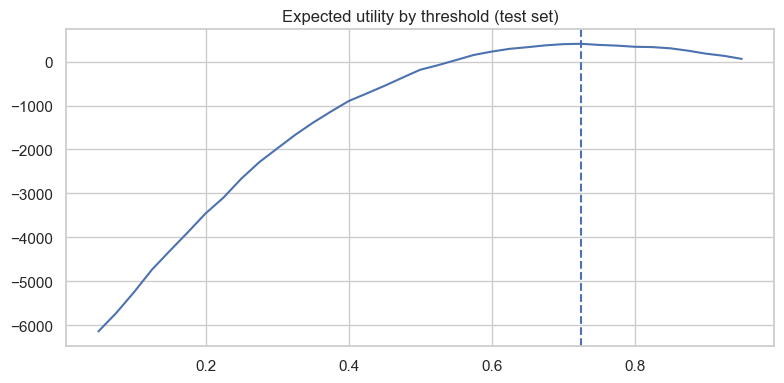

In [20]:
test_proba = best_models["logistic_regression"].predict_proba(X_test)[:, 1]
action_cost = 2.0
save_prob = 0.35
saved_value = 18.0

rows = []
for threshold in np.linspace(0.05, 0.95, 37):
    pred = (test_proba >= threshold).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    targeted = int(pred.sum())
    expected_utility = tp * (save_prob * saved_value - action_cost) - fp * action_cost
    rows.append({
        "threshold": threshold,
        "targeted": targeted,
        "tp": tp,
        "fp": fp,
        "precision": tp / targeted if targeted > 0 else np.nan,
        "recall": tp / y_test.sum() if y_test.sum() > 0 else np.nan,
        "expected_utility": expected_utility,
    })
utility_df = pd.DataFrame(rows)
best_utility_row = utility_df.sort_values("expected_utility", ascending=False).iloc[0]
display(best_utility_row.to_frame("value"))

plt.figure(figsize=(8,4))
plt.plot(utility_df["threshold"], utility_df["expected_utility"])
plt.axvline(best_utility_row["threshold"], linestyle="--")
plt.title("Expected utility by threshold (test set)")
plt.tight_layout()
plt.show()

The optimal threshold on the test set is **0.725**, targeting **433 users** (9% of test) with **47% precision** and **37% recall**, for an expected utility of **406.6 units**. This is a relatively aggressive threshold — it contacts a small slice of the population and captures over a third of churners.

However, this threshold is calibrated for a ~11% churn rate. Since the EDA shows a clear downward trend in churn over time, this threshold will likely become too aggressive on future data: as the base rate drops, the same cutoff will produce more false positives and fewer true positives, eroding both precision and utility. In production, the threshold should be recalibrated periodically as the churn rate evolves — the utility framework itself is sound, but its optimal operating point is not stationary.

## 8. Holdout evaluation

In [21]:
hold_rows = []
for name, model in best_models.items():
    proba = model.predict_proba(X_holdout)[:, 1]
    hold_rows.append({"model": name, "avg_precision": average_precision_score(y_holdout, proba), "roc_auc": roc_auc_score(y_holdout, proba)})

holdout_results_df = pd.DataFrame(hold_rows).sort_values("avg_precision", ascending=False).reset_index(drop=True)
display(holdout_results_df)

# Compare churn rates
print("\nChurn rate shift:")
print(f"  Train: {y_train.mean():.4f}")
print(f"  Test:  {y_test.mean():.4f}")
print(f"  Holdout: {y_holdout.mean():.4f}")

,model,avg_precision,roc_auc
0,gradient_boosting,0.143500,0.616169
1,logistic_regression,0.142324,0.611305
2,random_forest,0.116436,0.616636



Churn rate shift:
  Train: 0.1362
  Test:  0.1108
  Holdout: 0.0540


In [22]:
best_threshold = float(best_utility_row["threshold"])
logit_holdout_proba = best_models["logistic_regression"].predict_proba(X_holdout)[:, 1]
logit_holdout_pred = (logit_holdout_proba >= best_threshold).astype(int)

tp = int(((logit_holdout_pred == 1) & (y_holdout == 1)).sum())
fp = int(((logit_holdout_pred == 1) & (y_holdout == 0)).sum())
fn = int(((logit_holdout_pred == 0) & (y_holdout == 1)).sum())

holdout_expected_utility = tp * (save_prob * saved_value - action_cost) - fp * action_cost

display(pd.DataFrame([{
    "threshold": best_threshold,
    "targeted": int(logit_holdout_pred.sum()),
    "tp": tp,
    "fp": fp,
    "fn": fn,
    "precision": tp / logit_holdout_pred.sum() if logit_holdout_pred.sum() > 0 else np.nan,
    "recall": tp / y_holdout.sum() if y_holdout.sum() > 0 else np.nan,
    "expected_utility": holdout_expected_utility,
}]))

,threshold,targeted,tp,fp,fn,precision,recall,expected_utility
0,0.725,26,9,17,120,0.346154,0.069767,4.7


,bucket,n_obs,n_churn,observed_churn_rate,lift_vs_base
0,0-10%,239,31,0.129707,2.400084
1,10-20%,239,19,0.079498,1.471019
2,20-30%,239,12,0.050209,0.929065
3,30-40%,238,9,0.037815,0.699726
4,40-50%,239,9,0.037657,0.696799
5,50-60%,239,9,0.037657,0.696799
6,60-70%,238,10,0.042017,0.777474
7,70-80%,239,12,0.050209,0.929065
8,80-90%,239,8,0.033473,0.619377
9,90-100%,238,10,0.042017,0.777474


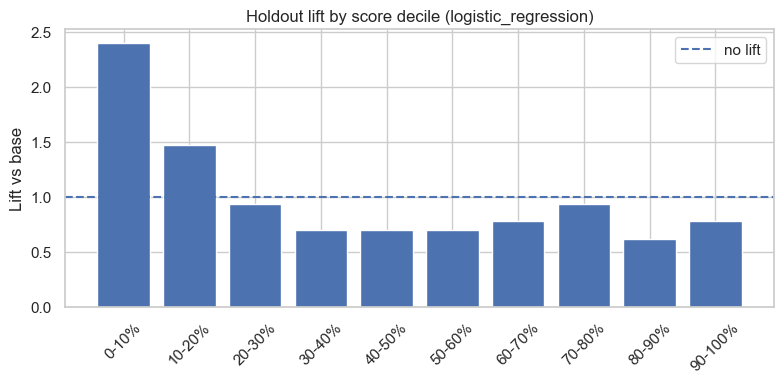

In [23]:
tmp = holdout_fe[["churn_next_week"]].copy()
tmp["score"] = logit_holdout_proba
tmp["score_rank_pct"] = tmp["score"].rank(pct=True)
base_rate = tmp["churn_next_week"].mean()
rows = []
for lower in range(0, 100, 10):
    upper = lower + 10
    pct_low = 1 - upper / 100
    pct_high = 1 - lower / 100
    if lower == 0:
        sub = tmp[(tmp["score_rank_pct"] >= pct_low) & (tmp["score_rank_pct"] <= pct_high)]
    else:
        sub = tmp[(tmp["score_rank_pct"] >= pct_low) & (tmp["score_rank_pct"] < pct_high)]
    rate = sub["churn_next_week"].mean()
    rows.append({"bucket": f"{lower}-{upper}%", "n_obs": len(sub), "n_churn": int(sub["churn_next_week"].sum()), "observed_churn_rate": rate, "lift_vs_base": rate / base_rate if base_rate > 0 else np.nan})
holdout_bucket_df = pd.DataFrame(rows)
display(holdout_bucket_df)

plt.figure(figsize=(8,4))
plt.bar(holdout_bucket_df["bucket"], holdout_bucket_df["lift_vs_base"])
plt.axhline(1.0, linestyle="--", label="no lift")
plt.xticks(rotation=45)
plt.ylabel("Lift vs base")
plt.title("Holdout lift by score decile (logistic_regression)")
plt.legend()
plt.tight_layout()
plt.show()

### Interpreting the holdout degradation

The holdout shows a sharp performance drop: AP falls from 0.41 (test) to 0.14, and AUC from 0.81 to 0.61. The utility at the test-optimal threshold collapses from 406.6 to 4.7.

**This is primarily a discrimination problem, not just a calibration problem.** AUC measures pure ranking ability — it is invariant to the base rate by construction. If AUC drops from 0.81 to 0.61, the model is genuinely worse at telling churners from non-churners on the holdout, not just miscalibrated.

The most likely explanation is **dataset shift**: the population that churns on the holdout is structurally different from the training population. The churn rate drops from 13.6% to 5.4%, which means the "easy" churners (very new, very inactive, paid channel + basic plan) have already left during the earlier period. What remains are harder-to-detect cases — users who resemble non-churners more closely. The model learned to separate the easy cases but struggles with the residual ones.

**The decile analysis confirms that predictive power concentrates in the top bucket.** The top decile shows a 2.4× lift, and the top 20% shows a 1.5× lift. But from decile 3 onward, the ranking is essentially flat and non-monotone (lifts fluctuate between 0.6× and 1.0× with no pattern). This is consistent with an AUC of 0.61: the model identifies the most at-risk users but is quasi-random for the rest of the population.

**The utility framework is particularly affected.** The test-optimal threshold of 0.725 targets only 26 holdout users (vs 433 on test), capturing just 9 churners for a net utility of 4.7. The threshold was calibrated for an 11% churn world and is far too aggressive for a 5% churn world.

**Implications:** Platt scaling or recalibration of probabilities would help adjust the threshold, but it would not fix the underlying ranking degradation. The real fix is to retrain on more recent data so the model learns to separate the current population's churners, not last quarter's.

## 9. Statistical significance of holdout performance

With ~2,400 holdout observations and ~129 churn events, the holdout is large enough for meaningful inference. I use a permutation test to assess whether the model's ranking performance is distinguishable from random.

Observed AP: 0.1423
Permutation null mean: 0.0567
Permutation p-value: 0.0000


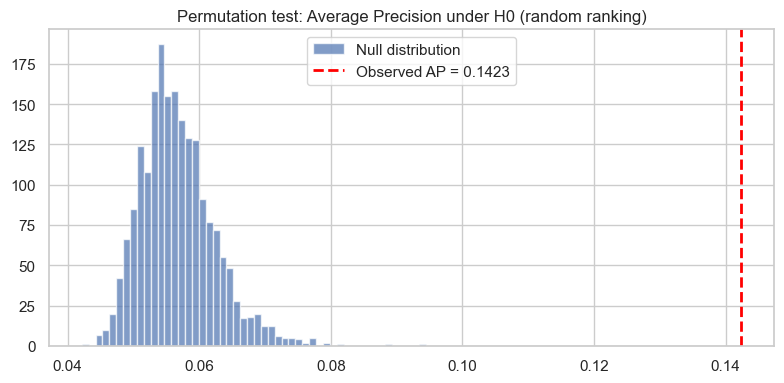

In [24]:
from sklearn.metrics import average_precision_score

np.random.seed(42)
n_perm = 2000

logit_holdout_proba = best_models["logistic_regression"].predict_proba(X_holdout)[:, 1]
observed_ap = average_precision_score(y_holdout, logit_holdout_proba)

perm_aps = []
for _ in range(n_perm):
    y_perm = np.random.permutation(y_holdout.values)
    perm_aps.append(average_precision_score(y_perm, logit_holdout_proba))

perm_aps = np.array(perm_aps)
p_value = (perm_aps >= observed_ap).mean()

print(f"Observed AP: {observed_ap:.4f}")
print(f"Permutation null mean: {perm_aps.mean():.4f}")
print(f"Permutation p-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_aps, bins=50, edgecolor="white", alpha=0.7, label="Null distribution")
ax.axvline(observed_ap, color="red", linestyle="--", linewidth=2, label=f"Observed AP = {observed_ap:.4f}")
ax.set_title("Permutation test: Average Precision under H0 (random ranking)")
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
# Bootstrap CI on holdout AP
boot_aps = []
for _ in range(2000):
    idx = np.random.choice(len(y_holdout), size=len(y_holdout), replace=True)
    y_b = y_holdout.values[idx]
    p_b = logit_holdout_proba[idx]
    if y_b.sum() == 0:
        continue
    boot_aps.append(average_precision_score(y_b, p_b))

boot_aps = np.array(boot_aps)
print(f"Holdout AP: {observed_ap:.4f}")
print(f"Bootstrap 95% CI: [{np.percentile(boot_aps, 2.5):.4f}, {np.percentile(boot_aps, 97.5):.4f}]")

Holdout AP: 0.1423
Bootstrap 95% CI: [0.0984, 0.2125]


The permutation test gives p = 0.0000 — the observed AP of 0.142 is far above the null mean of 0.057, confirming that the model does better than random. The bootstrap 95% CI on holdout AP is [0.098, 0.213], which is relatively tight.

However, "better than random" is a low bar. An AUC of 0.61 means the model is only marginally better than a coin flip at discriminating churners from non-churners across the full population. The statistical significance confirms that the *top-decile concentration* is real (not noise), but it does not salvage the model's inability to rank the remaining 90% of users.

## 10. Diagnosing the holdout degradation: AUC over time and churner profile shift

Two questions need answering: (1) is the discrimination loss gradual or sudden — i.e. does the model decay steadily over the holdout weeks, or is it uniformly weak? And (2) do holdout churners look different from train churners — i.e. is there a measurable profile shift that explains why the model struggles?

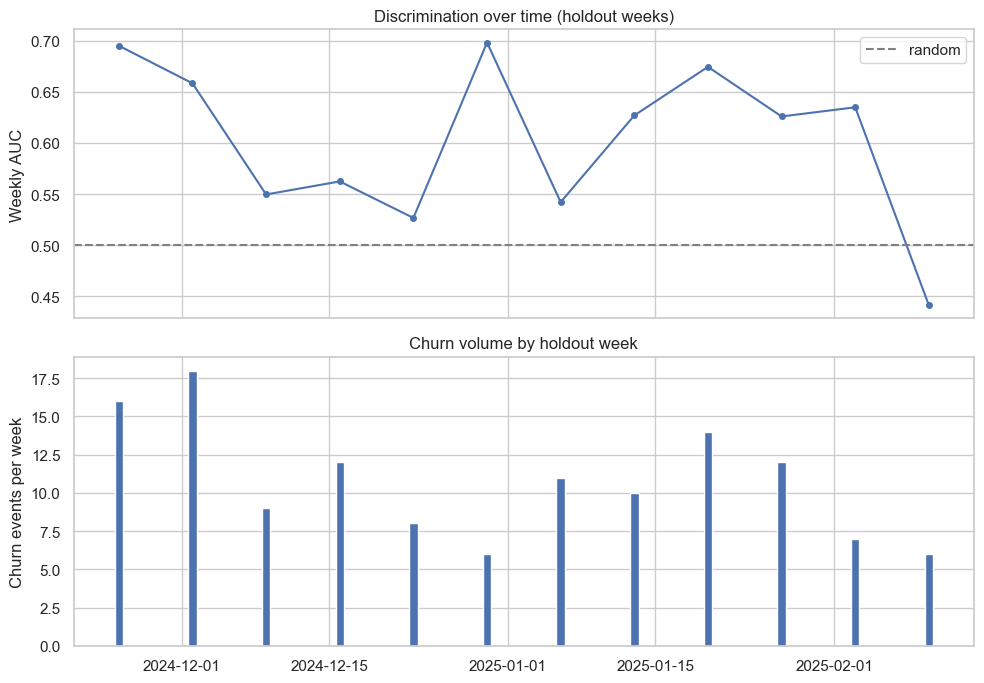

,week,auc,n,n_churn
0,2024-11-25,0.695030,265,16
1,2024-12-02,0.658249,249,18
2,2024-12-09,0.549550,231,9
3,2024-12-16,0.562302,222,12
4,2024-12-23,0.526609,210,8
5,2024-12-30,0.698129,202,6
6,2025-01-06,0.542015,196,11
7,2025-01-13,0.626857,185,10
8,2025-01-20,0.674357,175,14
9,2025-01-27,0.625839,161,12


,feature,train_churner_mean,holdout_churner_mean,holdout_non_churner_mean,shift,holdout_gap
0,weekly_sessions,4.098,7.341,8.475,3.243,-1.134
1,weekly_minutes,58.589,87.112,98.266,28.524,-11.154
2,weekly_spend,29.384,47.596,51.029,18.212,-3.433
3,tenure_weeks,4.577,27.388,27.164,22.811,0.224
4,feature_adoption_ratio,0.362,0.926,0.950,0.564,-0.024
5,support_tickets_week,0.476,0.450,0.308,-0.026,0.142
6,distinct_days_active,2.171,3.132,3.423,0.961,-0.291


In [26]:
# --- AUC by holdout week: how fast does discrimination decay? ---
from sklearn.metrics import roc_auc_score

holdout_with_score = holdout_fe[["week_start", "churn_next_week"]].copy()
holdout_with_score["score"] = best_models["logistic_regression"].predict_proba(X_holdout)[:, 1]

weekly_auc = []
for week, grp in holdout_with_score.groupby("week_start"):
    if grp["churn_next_week"].nunique() < 2:
        continue
    weekly_auc.append({"week": week, "auc": roc_auc_score(grp["churn_next_week"], grp["score"]), "n": len(grp), "n_churn": int(grp["churn_next_week"].sum())})

weekly_auc_df = pd.DataFrame(weekly_auc)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(weekly_auc_df["week"], weekly_auc_df["auc"], marker="o", markersize=4)
axes[0].axhline(0.5, linestyle="--", color="gray", label="random")
axes[0].set_ylabel("Weekly AUC")
axes[0].set_title("Discrimination over time (holdout weeks)")
axes[0].legend()

axes[1].bar(weekly_auc_df["week"], weekly_auc_df["n_churn"])
axes[1].set_ylabel("Churn events per week")
axes[1].set_title("Churn volume by holdout week")
plt.tight_layout()
plt.show()

display(weekly_auc_df)

# --- Churner profile shift: train vs holdout ---
profile_cols = ["weekly_sessions", "weekly_minutes", "weekly_spend", "tenure_weeks",
                "feature_adoption_ratio", "support_tickets_week", "distinct_days_active"]

train_churners = train_df.loc[train_df["churn_next_week"] == 1, profile_cols]
holdout_churners = holdout_fe.loc[holdout_fe["churn_next_week"] == 1, profile_cols]
holdout_non_churners = holdout_fe.loc[holdout_fe["churn_next_week"] == 0, profile_cols]

shift_rows = []
for col in profile_cols:
    shift_rows.append({
        "feature": col,
        "train_churner_mean": round(train_churners[col].mean(), 3),
        "holdout_churner_mean": round(holdout_churners[col].mean(), 3),
        "holdout_non_churner_mean": round(holdout_non_churners[col].mean(), 3),
        "shift": round(holdout_churners[col].mean() - train_churners[col].mean(), 3),
    })

shift_df = pd.DataFrame(shift_rows)
shift_df["holdout_gap"] = round(shift_df["holdout_churner_mean"] - shift_df["holdout_non_churner_mean"], 3)
display(shift_df)

The weekly AUC fluctuates between 0.44 and 0.71 with no clear downward trend — the degradation is structural, not a gradual staleness effect.

The profile shift table explains why. Holdout churners have 7.3 sessions (vs 4.1 in train), 87 minutes (vs 59), tenure of 27 weeks (vs 4.6), and higher spend. These are not disengaged newcomers — they are established, active users. The holdout_gap column confirms the consequence: churner/non-churner separation shrinks dramatically (sessions gap -1.1 vs -2.8 in training), making discrimination mechanically harder.

The current feature set captures whether users are engaged. Improving on this population would require features that capture why engaged users leave — contract terms, competitor activity, price sensitivity.

## Final remarks

The model produces a weekly churn score with genuine top-decile value: 2.4× lift on holdout, confirmed by permutation test (p < 0.001). For flagging the top 5–10% of users for retention outreach, this is operationally useful.

The central limitation is **dataset shift**. AUC drops from 0.81 to 0.61, and the profile analysis shows why: holdout churners are established, active users (27 weeks tenure, 7.3 sessions) who look nothing like the disengaged newcomers the model was trained to detect. The feature set captures *whether* users are engaged — but the residual churners leave for reasons engagement metrics do not reflect.

**What I would do next:**
- **Retrain on recent data every 4–8 weeks** to track the evolving churner population — the weekly AUC shows no gradual decay, so the issue is population shift, not model staleness
- **Expand the feature space toward churn *reasons***: contract proximity, price change exposure, competitor contact, satisfaction proxies — these are more likely to separate engaged-but-leaving users from engaged-and-staying ones
- **Recalibrate the threshold independently from retraining**: the utility-optimal cutoff of 0.725 was calibrated for 11% churn and collapses at 5% — a cheap rolling recalibration would partially restore utility even without retraining
- **Run a rolling backtest** to quantify how fast discrimination decays and set a principled retrain cadence